# Notebook 2 : Approches ML Classiques

Ce notebook compare différentes représentations textuelles avec des algorithmes de ML classiques :

**Représentations testées :**
- Bag of Words (BOW)
- TF-IDF
- Embeddings pré-entraînés (Sentence-BERT)

**Algorithmes testés :**
- Logistic Regression
- SVM
- Naive Bayes
- Random Forest

**Tâches :**
- Classification de polarité (3 classes : positive, negative, neutral)
- Classification de rating (5 classes : 1-5 étoiles)

## 1. Imports et Configuration

In [3]:
# Imports standards
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import warnings
warnings.filterwarnings('ignore')

# Preprocessing
import sys
sys.path.append('../src')
from utils import preprocess_dataframe, load_json_lines

# Pour BOW et TF-IDF
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Pour les embeddings pré-entraînés
from sentence_transformers import SentenceTransformer

# Modèles ML classiques
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

# Pour sauvegarder les résultats
import pickle
import json
import os

# Configuration
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Style des plots
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

print("Imports réussis")

Imports réussis


## 2. Chargement et Preprocessing des Données

In [4]:
# Charger les données
df = load_json_lines('../data/raw/yelp_academic_reviews4students.jsonl')

print(f"Dataset original : {len(df)} reviews")
print(f"Colonnes : {df.columns.tolist()}")

  Chargé 100,000 lignes...
  Chargé 200,000 lignes...
  Chargé 300,000 lignes...
  Chargé 400,000 lignes...
  Chargé 500,000 lignes...
  Chargé 600,000 lignes...
  Chargé 700,000 lignes...
  Chargé 800,000 lignes...
  Chargé 900,000 lignes...
  Chargé 1,000,000 lignes...
Dataset original : 1000000 reviews
Colonnes : ['review_id', 'user_id', 'business_id', 'stars', 'useful', 'funny', 'cool', 'text', 'date']


In [5]:
# Preprocessing avec ta fonction
df = preprocess_dataframe(
    df,
    text_column='text',
    rating_column='stars',
    lowercase=True,
    remove_punctuation=False,
    remove_numbers = False,
    add_polarity=True,
    add_rating=True,
    min_words=10,
    truncate=False
)

print(f"\nDataset après preprocessing : {len(df)} reviews")


Dataset après preprocessing : 997911 reviews



Polarité :
polarite
positive    668925
negative    230466
neutral      98520
Name: count, dtype: int64

Rating :
rating
5    461597
4    207328
1    152916
3     98520
2     77550
Name: count, dtype: int64


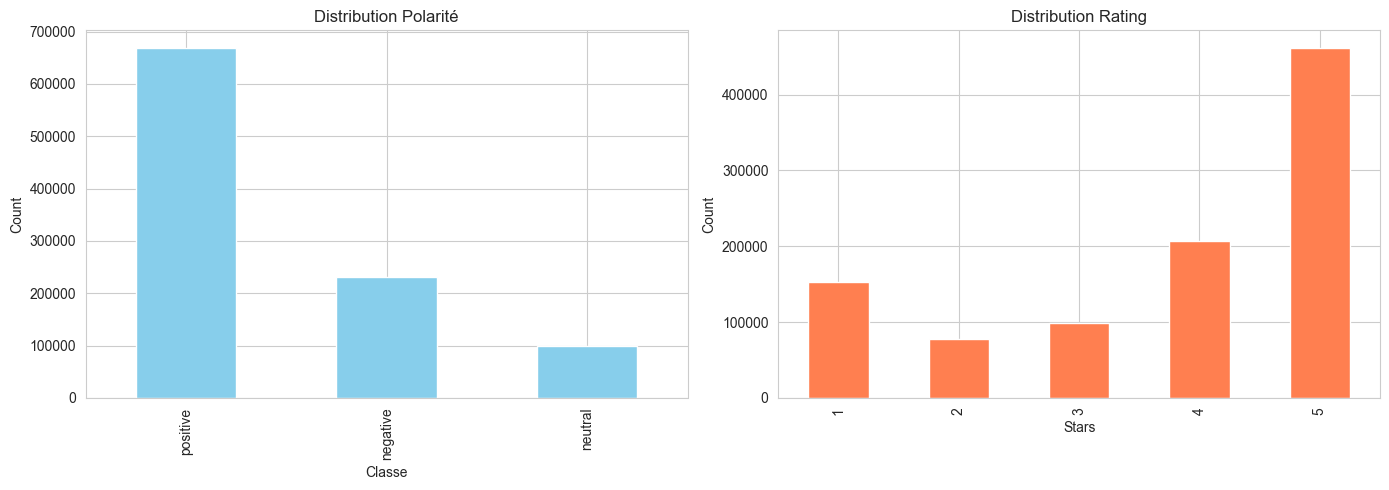

In [6]:
print(f"\nPolarité :")
print(df['polarite'].value_counts())
print(f"\nRating :")
print(df['rating'].value_counts())

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['polarite'].value_counts().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Distribution Polarité')
axes[0].set_xlabel('Classe')
axes[0].set_ylabel('Count')

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribution Rating')
axes[1].set_xlabel('Stars')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. Train/Test Split

In [7]:
# Split pour la tâche POLARITÉ (3 classes)
X_train, X_test, y_train_pol, y_test_pol = train_test_split(
    df['text_clean'], 
    df['polarite'],
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=df['polarite']
)

# Split pour la tâche RATING (5 classes)
_, _, y_train_rating, y_test_rating = train_test_split(
    df['text_clean'], 
    df['rating'],
    test_size=0.2, 
    random_state=RANDOM_STATE,
    stratify=df['rating']
)

print(f"Train set : {len(X_train)} reviews")
print(f"Test set  : {len(X_test)} reviews")
print(f"\nTrain polarité distribution :")
print(y_train_pol.value_counts())

Train set : 798328 reviews
Test set  : 199583 reviews

Train polarité distribution :
polarite
positive    535139
negative    184373
neutral      78816
Name: count, dtype: int64


## 4. Fonction d'Évaluation Commune

In [8]:
def evaluate_model(model, X_test, y_test, model_name, vectorizer=None):
    """
    Évalue un modèle et affiche les métriques.
    
    Args:
        model: Le modèle entraîné
        X_test: Données de test (texte ou features)
        y_test: Labels de test
        model_name: Nom du modèle pour l'affichage
        vectorizer: Vectorizer à appliquer si X_test est du texte
    
    Returns:
        dict: Dictionnaire avec les métriques
    """
    # Prédiction
    if vectorizer:
        X_test_transformed = vectorizer.transform(X_test)
        y_pred = model.predict(X_test_transformed)
    else:
        y_pred = model.predict(X_test)
    
    # Métriques
    acc = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    
    print(f"\n{'='*60}")
    print(f" {model_name}")
    print(f"{'='*60}")
    print(f"Accuracy:     {acc:.4f}")
    print(f"F1-macro:     {f1_macro:.4f}")
    print(f"F1-weighted:  {f1_weighted:.4f}")
    print(f"\n{classification_report(y_test, y_pred)}")
    
    # Matrice de confusion
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=sorted(y_test.unique()), 
                yticklabels=sorted(y_test.unique()))
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()
    
    # Retourner les résultats pour comparaison
    return {
        'model': model_name,
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

# Liste pour stocker tous les résultats
results = []

print("Fonction d'évaluation définie")

Fonction d'évaluation définie


## 5. Approche 1 : Bag of Words (BOW)

Représentation la plus simple : comptage des occurrences de mots.

In [9]:
bow_vectorizer = CountVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    stop_words='english'
)

X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)

print(f"BOW shape: {X_train_bow.shape}")
print(f"Vocabulaire size: {len(bow_vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_bow.nnz / (X_train_bow.shape[0] * X_train_bow.shape[1])):.2%}")

BOW shape: (798328, 5000)
Vocabulaire size: 5000
Sparsity: 99.28%


### 5.1 BOW + Logistic Regression


 BOW + LogReg
Accuracy:     0.8215
F1-macro:     0.7279
F1-weighted:  0.8411

              precision    recall  f1-score   support

    negative       0.85      0.81      0.83     46093
     neutral       0.34      0.65      0.45     19704
    positive       0.96      0.85      0.90    133786

    accuracy                           0.82    199583
   macro avg       0.72      0.77      0.73    199583
weighted avg       0.87      0.82      0.84    199583



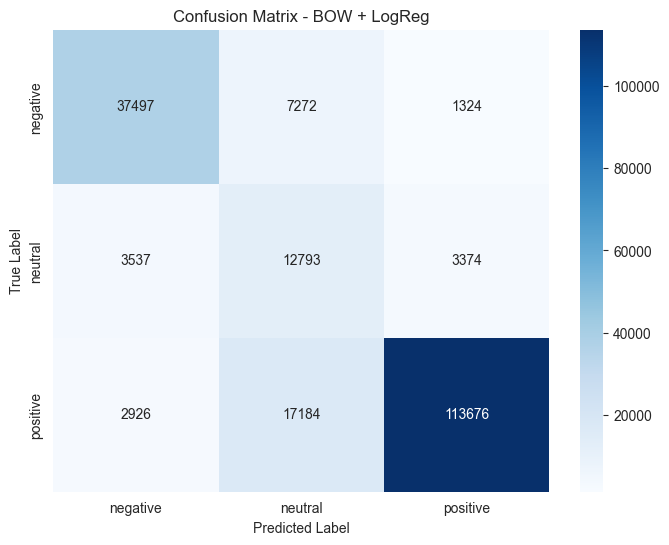

In [10]:
lr_bow = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    class_weight='balanced'
)

lr_bow.fit(X_train_bow, y_train_pol)
results.append(evaluate_model(lr_bow, X_test_bow, y_test_pol, "BOW + LogReg"))

### 5.2 BOW + Naive Bayes


 BOW + NaiveBayes
Accuracy:     0.7887
F1-macro:     0.6725
F1-weighted:  0.8029

              precision    recall  f1-score   support

    negative       0.72      0.72      0.72     46093
     neutral       0.33      0.53      0.41     19704
    positive       0.93      0.85      0.89    133786

    accuracy                           0.79    199583
   macro avg       0.66      0.70      0.67    199583
weighted avg       0.82      0.79      0.80    199583



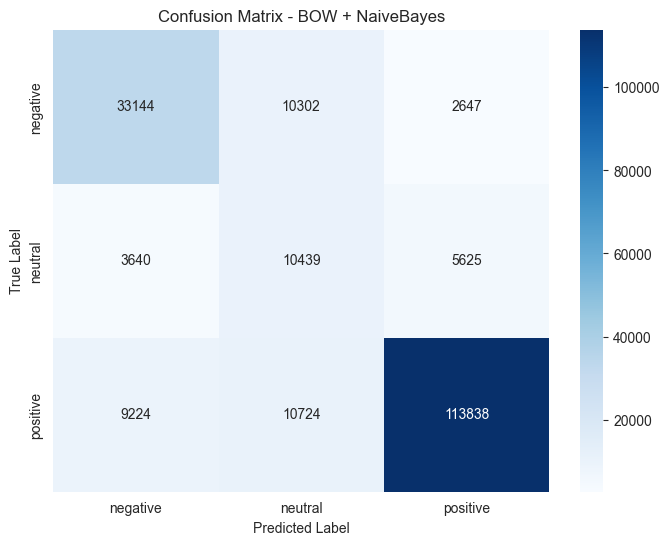

In [11]:
nb_bow = MultinomialNB()
nb_bow.fit(X_train_bow, y_train_pol)
results.append(evaluate_model(nb_bow, X_test_bow, y_test_pol, "BOW + NaiveBayes"))

### 5.3 BOW + Random Forest (optionnel)


 BOW + RandomForest
Accuracy:     0.7574
F1-macro:     0.4652
F1-weighted:  0.6956

              precision    recall  f1-score   support

    negative       0.91      0.39      0.55     46093
     neutral       0.00      0.00      0.00     19704
    positive       0.74      1.00      0.85    133786

    accuracy                           0.76    199583
   macro avg       0.55      0.46      0.47    199583
weighted avg       0.71      0.76      0.70    199583



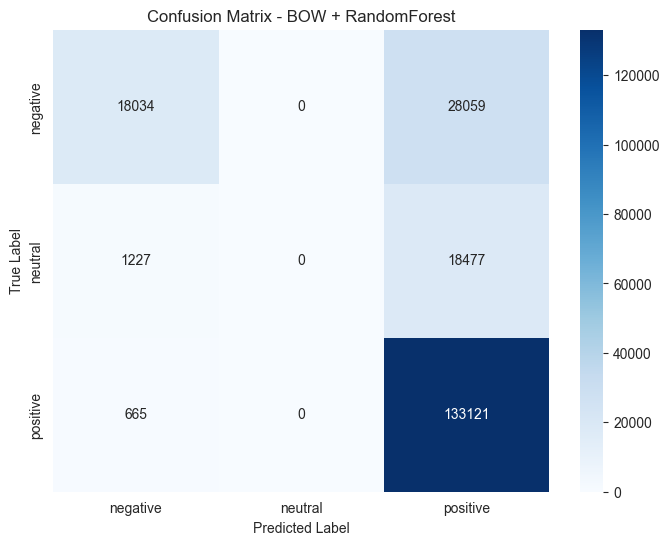

In [12]:
rf_bow = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20
)
rf_bow.fit(X_train_bow, y_train_pol)
results.append(evaluate_model(rf_bow, X_test_bow, y_test_pol, "BOW + RandomForest"))

## 6. Approche 2 : TF-IDF

Pondération des mots par leur importance (terme fréquence × inverse document fréquence).

In [13]:
# Vectorisation
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8,
    ngram_range=(1, 2),
    stop_words='english',
    sublinear_tf=True
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print(f"TF-IDF shape: {X_train_tfidf.shape}")
print(f"Vocabulaire size: {len(tfidf_vectorizer.vocabulary_)}")
print(f"Sparsity: {(1.0 - X_train_tfidf.nnz / (X_train_tfidf.shape[0] * X_train_tfidf.shape[1])):.2%}")

TF-IDF shape: (798328, 5000)
Vocabulaire size: 5000
Sparsity: 99.23%


### 6.1 TF-IDF + Logistic Regression


 TF-IDF + LogReg
Accuracy:     0.8192
F1-macro:     0.7299
F1-weighted:  0.8403

              precision    recall  f1-score   support

    negative       0.85      0.82      0.83     46093
     neutral       0.34      0.68      0.46     19704
    positive       0.97      0.84      0.90    133786

    accuracy                           0.82    199583
   macro avg       0.72      0.78      0.73    199583
weighted avg       0.88      0.82      0.84    199583



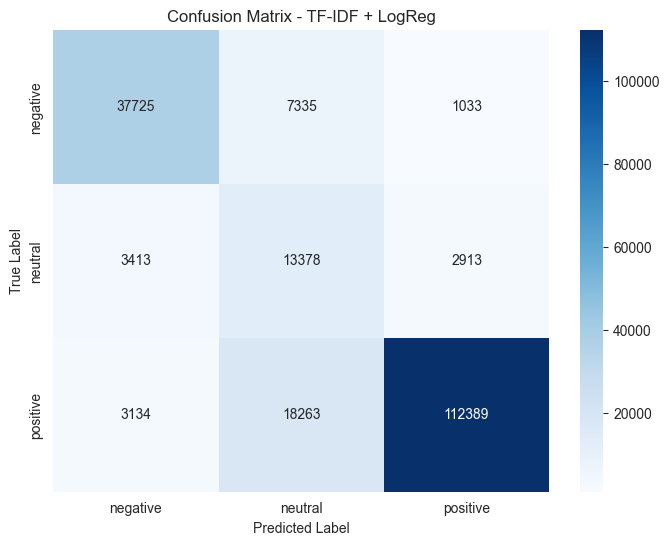

In [14]:
lr_tfidf = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    class_weight='balanced'
)

lr_tfidf.fit(X_train_tfidf, y_train_pol)
results.append(evaluate_model(lr_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + LogReg"))

### 6.2 TF-IDF + SVM


 TF-IDF + SVM
Accuracy:     0.8640
F1-macro:     0.7449
F1-weighted:  0.8647

              precision    recall  f1-score   support

    negative       0.83      0.86      0.85     46093
     neutral       0.46      0.46      0.46     19704
    positive       0.94      0.92      0.93    133786

    accuracy                           0.86    199583
   macro avg       0.74      0.75      0.74    199583
weighted avg       0.87      0.86      0.86    199583



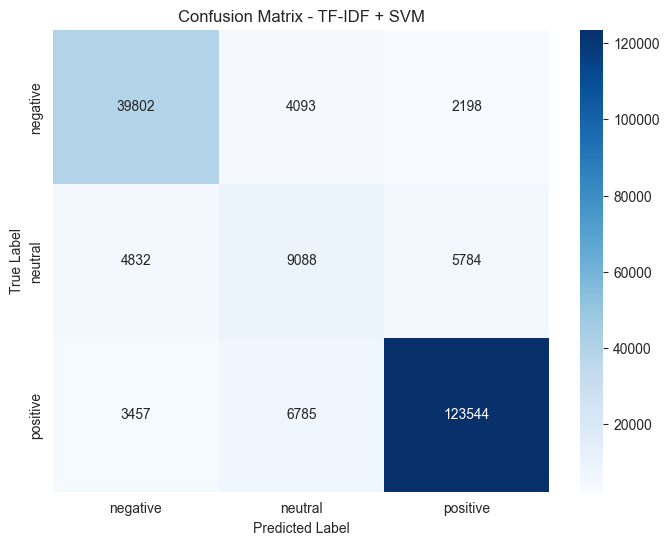

In [15]:
svm_tfidf = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

svm_tfidf.fit(X_train_tfidf, y_train_pol)
results.append(evaluate_model(svm_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + SVM"))

### 6.3 TF-IDF + Naive Bayes


 TF-IDF + NaiveBayes
Accuracy:     0.8273
F1-macro:     0.6066
F1-weighted:  0.7961

              precision    recall  f1-score   support

    negative       0.80      0.75      0.78     46093
     neutral       0.46      0.09      0.15     19704
    positive       0.84      0.96      0.90    133786

    accuracy                           0.83    199583
   macro avg       0.70      0.60      0.61    199583
weighted avg       0.80      0.83      0.80    199583



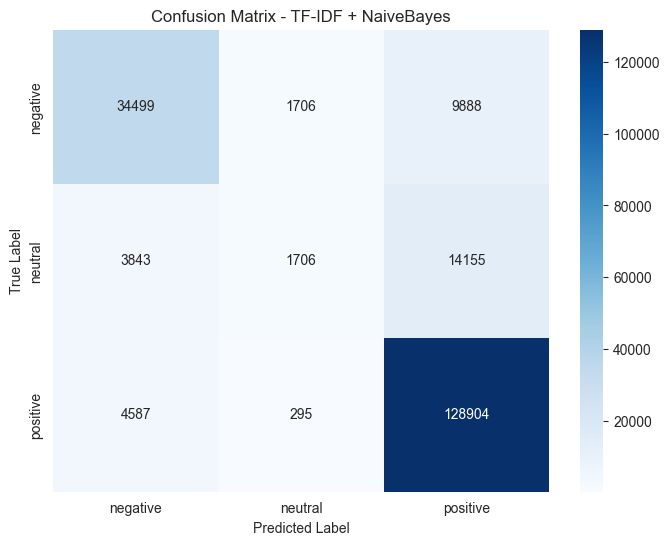

In [16]:
nb_tfidf = MultinomialNB()
nb_tfidf.fit(X_train_tfidf, y_train_pol)
results.append(evaluate_model(nb_tfidf, X_test_tfidf, y_test_pol, "TF-IDF + NaiveBayes"))

## 7. Approche 3 : Embeddings Pré-entraînés (Sentence-BERT)

Utilisation de modèles de langage pré-entraînés pour obtenir des représentations denses et sémantiques.

In [17]:

# Charger le modèle Sentence-BERT
# Modèles disponibles :
# - 'all-MiniLM-L6-v2' : 384 dim, rapide, bon compromis
# - 'all-mpnet-base-v2' : 768 dim, meilleur mais plus lent
# - 'paraphrase-MiniLM-L6-v2' : 384 dim, bon pour similarité

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

print(f"Modèle chargé : {embedding_model}")
print(f"Dimension des embeddings : {embedding_model.get_sentence_embedding_dimension()}")

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 269.20it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modèle chargé : SentenceTransformer(
  (0): Transformer({'max_seq_length': 256, 'do_lower_case': False, 'architecture': 'BertModel'})
  (1): Pooling({'word_embedding_dimension': 384, 'pooling_mode_cls_token': False, 'pooling_mode_mean_tokens': True, 'pooling_mode_max_tokens': False, 'pooling_mode_mean_sqrt_len_tokens': False, 'pooling_mode_weightedmean_tokens': False, 'pooling_mode_lasttoken': False, 'include_prompt': True})
  (2): Normalize()
)
Dimension des embeddings : 384


In [ ]:
# Générer les embeddings en multi-process (utilise tous les coeurs CPU)
pool = embedding_model.start_multi_process_pool()

X_train_embeddings = embedding_model.encode(
    X_train.tolist(),
    pool=pool,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

X_test_embeddings = embedding_model.encode(
    X_test.tolist(),
    pool=pool,
    batch_size=128,
    show_progress_bar=True,
    convert_to_numpy=True
)

embedding_model.stop_multi_process_pool(pool)

print(f"\nTrain embeddings shape: {X_train_embeddings.shape}")
print(f"Test embeddings shape: {X_test_embeddings.shape}")

### 7.1 Embeddings + Logistic Regression

In [ ]:

lr_emb = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    class_weight='balanced'
)

lr_emb.fit(X_train_embeddings, y_train_pol)
results.append(evaluate_model(lr_emb, X_test_embeddings, y_test_pol, "Embeddings + LogReg"))

### 7.2 Embeddings + SVM

In [ ]:

svm_emb = LinearSVC(
    max_iter=2000, 
    random_state=RANDOM_STATE,
    class_weight='balanced'
)

svm_emb.fit(X_train_embeddings, y_train_pol)
results.append(evaluate_model(svm_emb, X_test_embeddings, y_test_pol, "Embeddings + SVM"))

### 7.3 Embeddings + Random Forest

In [ ]:

rf_emb = RandomForestClassifier(
    n_estimators=100, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    max_depth=20,
    class_weight='balanced'
)

rf_emb.fit(X_train_embeddings, y_train_pol)
results.append(evaluate_model(rf_emb, X_test_embeddings, y_test_pol, "Embeddings + RandomForest"))

## 8. Comparaison des Résultats

In [ ]:


# Créer un DataFrame de comparaison
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('accuracy', ascending=False)

print("\n" + results_df.to_string(index=False))

# Identifier le meilleur modèle
best_model = results_df.iloc[0]
print(f"\n Meilleur modèle : {best_model['model']}")
print(f"   Accuracy: {best_model['accuracy']:.4f}")
print(f"   F1-macro: {best_model['f1_macro']:.4f}")

In [ ]:
# Visualisation comparative
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Accuracy
results_df.plot(x='model', y='accuracy', kind='barh', ax=axes[0], legend=False, color='skyblue')
axes[0].set_title('Accuracy', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Score', fontsize=12)
axes[0].set_xlim([0, 1])
axes[0].grid(axis='x', alpha=0.3)

# F1-macro
results_df.plot(x='model', y='f1_macro', kind='barh', ax=axes[1], legend=False, color='lightcoral')
axes[1].set_title('F1-Macro', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Score', fontsize=12)
axes[1].set_xlim([0, 1])
axes[1].grid(axis='x', alpha=0.3)

# F1-weighted
results_df.plot(x='model', y='f1_weighted', kind='barh', ax=axes[2], legend=False, color='lightgreen')
axes[2].set_title('F1-Weighted', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Score', fontsize=12)
axes[2].set_xlim([0, 1])
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ml_classique_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nGraphique sauvegardé : ../results/ml_classique_comparison.png")

## 9. Sauvegarde des Résultats et Modèles

In [ ]:
# Créer les dossiers si nécessaire
os.makedirs('../results', exist_ok=True)
os.makedirs('../models', exist_ok=True)

# Sauvegarder les résultats
results_df.to_csv('../results/ml_classique_results.csv', index=False)
print("Résultats sauvegardés : ../results/ml_classique_results.csv")

# Sauvegarder les meilleurs modèles
# Exemple : sauvegarder le meilleur TF-IDF et le meilleur Embeddings

# TF-IDF vectorizer + modèle
with open('../models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

with open('../models/tfidf_logreg.pkl', 'wb') as f:
    pickle.dump(lr_tfidf, f)

print("Modèle TF-IDF sauvegardé : ../models/tfidf_*")

# Embeddings model (pas besoin de sauvegarder le SentenceTransformer, on peut le recharger)
with open('../models/embeddings_logreg.pkl', 'wb') as f:
    pickle.dump(lr_emb, f)

print("Modèle Embeddings sauvegardé : ../models/embeddings_logreg.pkl")

# Sauvegarder les méta-données
metadata = {
    'best_model': best_model['model'],
    'best_accuracy': float(best_model['accuracy']),
    'best_f1_macro': float(best_model['f1_macro']),
    'embedding_model': 'all-MiniLM-L6-v2',
    'train_size': len(X_train),
    'test_size': len(X_test),
    'random_state': RANDOM_STATE
}

with open('../results/ml_classique_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print("Métadonnées sauvegardées : ../results/ml_classique_metadata.json")

## 10. (Optionnel) Test sur la Tâche RATING

On teste le meilleur modèle sur la prédiction du rating (5 classes).

In [ ]:
# On prend le meilleur modèle (généralement TF-IDF ou Embeddings)
# Exemple avec TF-IDF + LogReg

lr_rating = LogisticRegression(
    max_iter=1000, 
    random_state=RANDOM_STATE, 
    n_jobs=-1,
    class_weight='balanced'
)

lr_rating.fit(X_train_tfidf, y_train_rating)

y_pred_rating = lr_rating.predict(X_test_tfidf)
acc_rating = accuracy_score(y_test_rating, y_pred_rating)
f1_rating = f1_score(y_test_rating, y_pred_rating, average='weighted')

print(f"\nTF-IDF + LogReg sur RATING")
print(f"Accuracy:     {acc_rating:.4f}")
print(f"F1-weighted:  {f1_rating:.4f}")
print(f"\n{classification_report(y_test_rating, y_pred_rating)}")

# Matrice de confusion
cm_rating = confusion_matrix(y_test_rating, y_pred_rating)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rating, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=[1, 2, 3, 4, 5], 
            yticklabels=[1, 2, 3, 4, 5])
plt.title('Confusion Matrix - Rating Prediction')
plt.ylabel('True Rating')
plt.xlabel('Predicted Rating')
plt.show()

## 11. Analyse des Erreurs (Optionnel)

Regardons quelques exemples mal classifiés pour comprendre les limites.

In [ ]:
# Prendre le meilleur modèle (ex: TF-IDF + LogReg)
y_pred_best = lr_tfidf.predict(X_test_tfidf)

# Trouver les erreurs
errors_df = pd.DataFrame({
    'text': X_test,
    'true_label': y_test_pol,
    'predicted_label': y_pred_best
})

errors_df['is_error'] = errors_df['true_label'] != errors_df['predicted_label']
errors = errors_df[errors_df['is_error']]

print(f"\nNombre d'erreurs : {len(errors)} / {len(X_test)} ({len(errors)/len(X_test)*100:.2f}%)")
print("\nQuelques exemples d'erreurs :")
print("="*80)

for i, row in errors.head(5).iterrows():
    print(f"\nTexte : {row['text'][:200]}...")
    print(f"Vrai label : {row['true_label']} | Prédit : {row['predicted_label']}")
    print("-"*80)

**Résumé des résultats :**

- **BOW** : Baseline simple, performances correctes
- **TF-IDF** : Amélioration grâce à la pondération et aux n-grammes
- **Embeddings** : Meilleure compréhension sémantique, généralement les meilleures performances